# Chapter 9 — Strain Gages and Murphy's Law
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 9 — Strain Gages and Murphy's Law.

In 1949 a set of strain-gage transducers, designed by Capt. Edward A. Murphy Jr. to measure the load in the harness of John Paul Stapp's deceleration sled at Muroc, returned a flat trace on a sled run. The survivors' accounts disagree on nearly every detail, including whether the transducers had worked on earlier runs, but they agree on the mechanism: the gages could be put together in more than one way, and one of those ways lost the signal the transducer was built to measure.

This notebook works that mechanism through the bridge equation. It uses a simplified model of a harness clamp link, a short bar that carries strap tension and is bent as it does so, with one gage on its top face (T) and one on its bottom face (B). None of the accounts reproduces Murphy's drawings, so the model illustrates the physics; it is not a reconstruction of his transducer. All values are illustrative.

**This notebook demonstrates:**
1. The chapter's worked example (Eq. 9.1) in five wirings: correct; gage B in the opposite arm; T and B exchanged; both gages turned 90° on their faces; both gages moved 90° around the link onto the neutral axis.
2. What the pre-run checks show: a shunt across a completion resistor in the conditioner, a shunt at a gage's own tabs, and a known-load check.
3. The figure in the chapter.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Generated figures are written next to the chapter's other media.
# The file name matches the \includegraphics call in Chapter 9.
OUT_DIR = Path("../src/media/ch09")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — The bridge equation and the clamp link

For small strains, with every arm of nominal resistance $R$ and gage factor $GF$, the Wheatstone bridge output is

$$\frac{V_\text{out}}{V_\text{ex}} = \frac{GF}{4}\left(\varepsilon_1 - \varepsilon_2 + \varepsilon_3 - \varepsilon_4\right) \qquad (9.1)$$

with the arms numbered as in Figure 26.1: arm 1 from $P{+}$ to $S{-}$, arm 2 from $P{+}$ to $S{+}$, arm 3 from $S{+}$ to $P{-}$, arm 4 from $S{-}$ to $P{-}$. A fixed completion resistor contributes zero strain. Opposite arms (1 and 3, 2 and 4) add; adjacent arms subtract.

The clamp link carries an axial (tension) strain $\varepsilon_a$, the same on both faces, and a bending strain $\pm\varepsilon_b$, positive on the top face and negative on the bottom:

$$\varepsilon_T = \varepsilon_a + \varepsilon_b, \qquad \varepsilon_B = \varepsilon_a - \varepsilon_b$$

A gage turned 90° on either face sits across a uniaxial stress and reads the Poisson strain, $-\nu$ times that face's lengthwise strain. A gage moved a quarter-turn around the link onto a side face, still aligned with the link, sits on the neutral axis of the bending and reads $\varepsilon_a$ alone.

In [2]:
GF = 2.00          # gage factor
V_EX = 5.0         # excitation, V
NU = 0.30          # Poisson's ratio of the link
EPS_B = 1000e-6    # bending strain at the faces under the test load
EPS_A = 100e-6     # axial (strap-tension) strain under the test load


def bridge(e1=0.0, e2=0.0, e3=0.0, e4=0.0):
    # Eq. 9.1: normalized bridge output, V/V
    return GF / 4.0 * (e1 - e2 + e3 - e4)


def cases(load_fraction=1.0):
    # Bridge output (mV/V) for each wiring at a fraction of the test load.
    eT = load_fraction * (EPS_A + EPS_B)       # top-face gage, along the link
    eB = load_fraction * (EPS_A - EPS_B)       # bottom-face gage, along the link
    eN = load_fraction * EPS_A                 # either gage moved onto the neutral axis
    out = {
        'A':  bridge(e1=eT, e4=eB),                    # correct: T arm 1, B arm 4 (adjacent)
        'B':  bridge(e1=eT, e3=eB),                    # B moved to arm 3 (opposite T)
        'C':  bridge(e1=eB, e4=eT),                    # T and B exchanged
        'D':  bridge(e1=-NU * eT, e4=-NU * eB),        # both turned 90 deg on their faces
        "D'": bridge(e1=eN, e4=eN),                    # both moved 90 deg around the link
    }
    return {k: v * 1e3 for k, v in out.items()}   # V/V -> mV/V


NAMES = {
    'A': 'correct',
    'B': 'B in opposite arm',
    'C': 'T and B exchanged',
    'D': 'turned 90° on faces',
    "D'": 'on neutral axis',
}

# Shunt calibration with a resistor sized by Eq. 29.2 to simulate
# -1000 microstrain in the arm it is placed across.
EPS_SHUNT = -1000e-6
# (1) across completion arm 2 inside the conditioner: arm 2 holds the same
#     resistor in every case, so the step is +0.500 mV/V every time.
shunt_cond = {k: bridge(e2=EPS_SHUNT) * 1e3 for k in NAMES}
# (2) across gage B's own tabs: the step's sign depends on the arm B is in.
B_ARM = {'A': 4, 'B': 3, 'C': 1, 'D': 4, "D'": 4}
def shunt_in_arm(arm):
    e = [0.0, 0.0, 0.0, 0.0]
    e[arm - 1] = EPS_SHUNT
    return bridge(*e) * 1e3
shunt_tabsB = {k: shunt_in_arm(B_ARM[k]) for k in NAMES}

full = cases(1.0)
expected = full['A']
print(f"{'case':24s} {'mV/V':>7s} {'mV':>7s} {'ratio':>7s} {'shunt,cond':>11s} {'shunt,B tabs':>13s}")
for k, v in full.items():
    print(f"{k:3s}{NAMES[k]:21s} {v:7.3f} {v * V_EX:7.2f} {v / expected:7.2f} "
          f"{shunt_cond[k]:11.3f} {shunt_tabsB[k]:13.3f}")

case                        mV/V      mV   ratio  shunt,cond  shunt,B tabs
A  correct                 1.000    5.00    1.00       0.500         0.500
B  B in opposite arm       0.100    0.50    0.10       0.500        -0.500
C  T and B exchanged      -1.000   -5.00   -1.00       0.500        -0.500
D  turned 90° on faces    -0.300   -1.50   -0.30       0.500         0.500
D' on neutral axis         0.000    0.00    0.00       0.500         0.500


---
## 2 — The figure

Panel (a) is a known-load check: the load on the link is raised in steps to the test load and the bridge output is recorded. Only the correct wiring lands on the expected line. Panel (b) is the shunt calibration of the same five bridges at two places. The shunt across completion arm 2 inside the conditioner returns exactly the expected step every time, because that arm holds the same resistor in every case; it checks gain and scaling. The shunt across gage B's own tabs reveals which arm B is in, so it catches cases B and C, but not D or D′, where the gages are in the right arms and only face the wrong way or sit in the wrong place. Cases are distinguished by line style, marker, and hatching as well as color, and labeled directly, so the figure reads in grayscale.

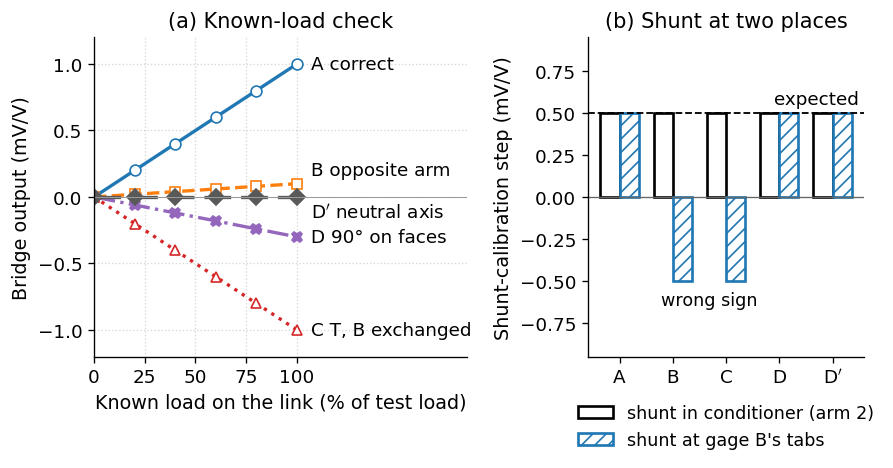

In [3]:
# Sized for print: the figure is printed 6.2 in wide, so at 7.6 in here
# every label below prints at 8.5 pt or more.
plt.rcParams.update({'font.size': 11.5, 'axes.titlesize': 12.5,
                     'axes.labelsize': 11.5, 'xtick.labelsize': 11, 'ytick.labelsize': 11})
SHORT = {'A': 'correct', 'B': 'opposite arm', 'C': 'T, B exchanged',
         'D': '90° on faces', "D'": 'neutral axis'}
fig, (axa, axb) = plt.subplots(1, 2, figsize=(7.6, 4.1),
                               gridspec_kw={'width_ratios': [1.35, 1.0]})

frac = np.linspace(0.0, 1.0, 6)
outs = {k: np.array([cases(f)[k] for f in frac]) for k in full}
style = {
    'A':  dict(color='tab:blue',   ls='-',  marker='o', mfc='white', dy=0.0),
    'B':  dict(color='tab:orange', ls='--', marker='s', mfc='white', dy=0.07),
    'C':  dict(color='tab:red',    ls=':',  marker='^', mfc='white', dy=0.0),
    'D':  dict(color='tab:purple', ls='-.', marker='X', mfc='tab:purple', dy=0.0),
    "D'": dict(color='0.35',       ls=(0, (8, 3)), marker='D', mfc='0.35', dy=-0.08),
}
for k, y in outs.items():
    s = style[k]
    axa.plot(frac * 100, y, color=s['color'], ls=s['ls'], marker=s['marker'],
             ms=6.5, lw=2.0, mfc=s['mfc'])
    lab = ("D$'$" if k == "D'" else k) + ' ' + SHORT[k]
    axa.annotate(lab, xy=(100, y[-1]), xytext=(107, y[-1] + s['dy'] * 1.4),
                 va='center', fontsize=11)
axa.axhline(0, color='0.6', lw=0.6)
axa.set_xlim(0, 184)
axa.set_xticks([0, 25, 50, 75, 100])
axa.set_ylim(-1.2, 1.2)
axa.set_xlabel('Known load on the link (% of test load)')
axa.set_ylabel('Bridge output (mV/V)')
axa.set_title('(a) Known-load check')
axa.grid(True, ls=':', alpha=0.5)
for sp in ('top', 'right'):
    axa.spines[sp].set_visible(False)

keys = list(NAMES)
x = np.arange(len(keys))
w = 0.36
v_cond = [shunt_cond[k] for k in keys]
v_tabs = [shunt_tabsB[k] for k in keys]
axb.bar(x - w / 2, v_cond, w, facecolor='white', edgecolor='black', linewidth=1.6,
        label='shunt in conditioner (arm 2)')
axb.bar(x + w / 2, v_tabs, w, facecolor='white', edgecolor='tab:blue', hatch='///',
        linewidth=1.6, label="shunt at gage B's tabs")
axb.axhline(0.5, color='black', ls='--', lw=1.1)
axb.axhline(0, color='0.4', lw=0.8)
axb.text(1.5 + w / 2, -0.56, 'wrong sign', ha='center', va='top', fontsize=10.5)
axb.set_xticks(x)
axb.set_xticklabels(['A', 'B', 'C', 'D', "D$'$"])
axb.set_ylim(-0.95, 0.95)
axb.set_ylabel('Shunt-calibration step (mV/V)')
axb.set_title('(b) Shunt at two places')
axb.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=1, fontsize=10.5,
           frameon=False)
axb.text(len(keys) - 0.5, 0.53, 'expected', ha='right', va='bottom', fontsize=11)
for sp in ('top', 'right'):
    axb.spines[sp].set_visible(False)

plt.tight_layout()
FIG_PATH = OUT_DIR / "fig09_nb1_miswiring_checks.png"
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

---
## Where to take this next

1. **Make the link pure bending.** Set `EPS_A = 0` and case B reads exactly zero: the flat line of Nichols's account. Then raise `EPS_A` and see how large the tension term must be before case B looks like a weak but plausible signal. Case D′ reads zero for every value of `EPS_A`.
2. **Go to a full bridge.** Put two gages on each face (arms 1 and 3 on top, 2 and 4 on the bottom) and swap one top gage with one bottom gage between adjacent arms. The output goes to zero for bending *and* tension. A shunt across a completion resistor cannot notice, because there is none; a shunt at each gage's tabs shows that two gages are in the wrong arms. What no shunt can show is which face a gage is bonded to.
3. **Turn one gage, not both.** Rotate only the top gage by 90° and work out what the bridge reads. It is neither the bending nor the tension, and it changes with the ratio `EPS_A / EPS_B`, which is why a single known-load point is weaker evidence than a load sweep.